# Support Vector Machines
Applies SVM with linear and RBF kernels across three healthcare datasets. Features are standardized before fitting since SVMs are sensitive to feature scale.

| Dataset | Target |
|---|---|
| df1 | DIABETE4 (diabetic vs not) |
| df2 | readmitted (<30 days) |
| df3 | stroke |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import LinearSVC
from sklearn.kernel_approximation import Nystroem
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve

## Load Data

In [2]:
df1 = pd.read_csv('df1_preprocessed.csv')
df2 = pd.read_csv('df2_preprocessed.csv')
df3 = pd.read_csv('df3_preprocessed.csv')

## Prep & Split

In [3]:
# df1
df1 = df1[df1['DIABETE4'].isin([0, 1])]
X1 = df1.drop(columns=['DIABETE4', '_RFCHOL3'])
y1 = df1['DIABETE4']
X1_tr, X1_te, y1_tr, y1_te = train_test_split(X1, y1, test_size=0.2, random_state=42)

sc1 = StandardScaler()
X1_tr_s = sc1.fit_transform(X1_tr)
X1_te_s = sc1.transform(X1_te)

In [4]:
# df2
X2 = df2.drop(columns=['readmitted'])
y2 = df2['readmitted']
X2_tr, X2_te, y2_tr, y2_te = train_test_split(X2, y2, test_size=0.2, random_state=42)

sc2 = StandardScaler()
X2_tr_s = sc2.fit_transform(X2_tr)
X2_te_s = sc2.transform(X2_te)

In [5]:
# df3
X3 = df3.drop(columns=['stroke'])
y3 = df3['stroke']
X3_tr, X3_te, y3_tr, y3_te = train_test_split(X3, y3, test_size=0.2, random_state=42)

sc3 = StandardScaler()
X3_tr_s = sc3.fit_transform(X3_tr)
X3_te_s = sc3.transform(X3_te)

## SVM — Linear Kernel

In [6]:
# df1 linear
svm1_lin = LinearSVC(C=1.0, random_state=42, max_iter=2000)
svm1_lin.fit(X1_tr_s, y1_tr)
auc1_lin = roc_auc_score(y1_te, svm1_lin.decision_function(X1_te_s))
print(f'df1 linear AUC: {auc1_lin:.4f}')

/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


df1 linear AUC: 0.8161


/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [7]:
# df2 linear
svm2_lin = LinearSVC(C=1.0, random_state=42, max_iter=2000)
svm2_lin.fit(X2_tr_s, y2_tr)
auc2_lin = roc_auc_score(y2_te, svm2_lin.decision_function(X2_te_s))
print(f'df2 linear AUC: {auc2_lin:.4f}')

/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


df2 linear AUC: 0.6738


/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [8]:
# df3 linear
svm3_lin = LinearSVC(C=1.0, random_state=42, max_iter=2000)
svm3_lin.fit(X3_tr_s, y3_tr)
auc3_lin = roc_auc_score(y3_te, svm3_lin.decision_function(X3_te_s))
print(f'df3 linear AUC: {auc3_lin:.4f}')

/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


df3 linear AUC: 0.8339


## SVM — RBF Kernel

In [9]:
# df1 RBF
svm1_rbf = make_pipeline(
    Nystroem(kernel='rbf', gamma=None, n_components=300, random_state=42),
    LinearSVC(C=1.0, max_iter=2000, random_state=42)
)
svm1_rbf.fit(X1_tr_s, y1_tr)
auc1_rbf = roc_auc_score(y1_te, svm1_rbf.decision_function(X1_te_s))
print(f'df1 RBF AUC: {auc1_rbf:.4f}')

/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


df1 RBF AUC: 0.8189


In [10]:
# df2 RBF
svm2_rbf = make_pipeline(
    Nystroem(kernel='rbf', gamma=None, n_components=300, random_state=42),
    LinearSVC(C=1.0, max_iter=2000, random_state=42)
)
svm2_rbf.fit(X2_tr_s, y2_tr)
auc2_rbf = roc_auc_score(y2_te, svm2_rbf.decision_function(X2_te_s))
print(f'df2 RBF AUC: {auc2_rbf:.4f}')

/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


df2 RBF AUC: 0.6703


In [11]:
# df3 RBF
svm3_rbf = make_pipeline(
    Nystroem(kernel='rbf', gamma=None, n_components=300, random_state=42),
    LinearSVC(C=1.0, max_iter=2000, random_state=42)
)
svm3_rbf.fit(X3_tr_s, y3_tr)
auc3_rbf = roc_auc_score(y3_te, svm3_rbf.decision_function(X3_te_s))
print(f'df3 RBF AUC: {auc3_rbf:.4f}')

df3 RBF AUC: 0.7879


/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


## Effect of C (Regularization) — RBF Kernel

/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/

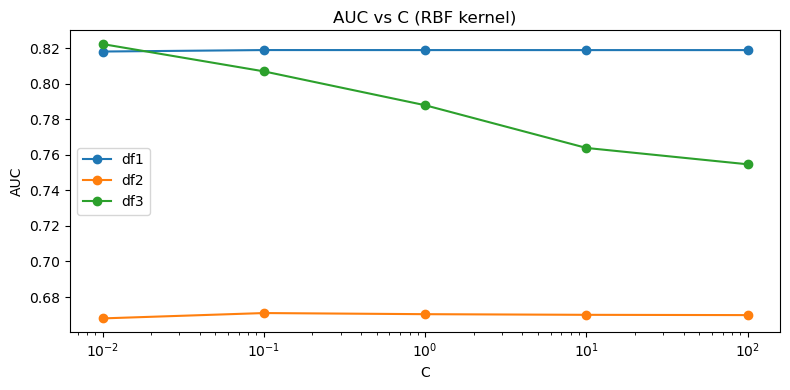

In [12]:
# sweep C values on each dataset
C_vals = [0.01, 0.1, 1, 10, 100]

aucs1_c, aucs2_c, aucs3_c = [], [], []

for c in C_vals:
    m1 = make_pipeline(
        Nystroem(kernel='rbf', gamma=None, n_components=300, random_state=42),
        LinearSVC(C=c, max_iter=2000, random_state=42)
    ).fit(X1_tr_s, y1_tr)
    aucs1_c.append(roc_auc_score(y1_te, m1.decision_function(X1_te_s)))

    m2 = make_pipeline(
        Nystroem(kernel='rbf', gamma=None, n_components=300, random_state=42),
        LinearSVC(C=c, max_iter=2000, random_state=42)
    ).fit(X2_tr_s, y2_tr)
    aucs2_c.append(roc_auc_score(y2_te, m2.decision_function(X2_te_s)))

    m3 = make_pipeline(
        Nystroem(kernel='rbf', gamma=None, n_components=300, random_state=42),
        LinearSVC(C=c, max_iter=2000, random_state=42)
    ).fit(X3_tr_s, y3_tr)
    aucs3_c.append(roc_auc_score(y3_te, m3.decision_function(X3_te_s)))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(C_vals, aucs1_c, marker='o', label='df1')
ax.plot(C_vals, aucs2_c, marker='o', label='df2')
ax.plot(C_vals, aucs3_c, marker='o', label='df3')
ax.set_xscale('log')
ax.set_xlabel('C')
ax.set_ylabel('AUC')
ax.set_title('AUC vs C (RBF kernel)')
ax.legend()
plt.tight_layout()
plt.show()

## ROC Curves

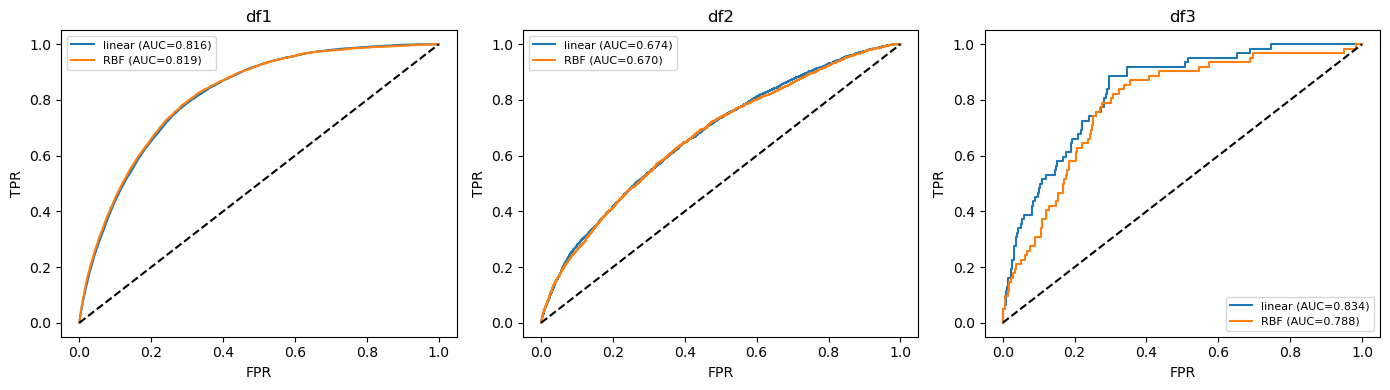

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, model_lin, model_rbf, X_te, y_te, label in zip(
    axes,
    [svm1_lin, svm2_lin, svm3_lin],
    [svm1_rbf, svm2_rbf, svm3_rbf],
    [X1_te_s, X2_te_s, X3_te_s],
    [y1_te, y2_te, y3_te],
    ['df1', 'df2', 'df3']
):
    for model, name in [(model_lin, 'linear'), (model_rbf, 'RBF')]:
        scores = model.decision_function(X_te)
        fpr, tpr, _ = roc_curve(y_te, scores)
        auc = roc_auc_score(y_te, scores)
        ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
    ax.plot([0,1],[0,1],'k--')
    ax.set_title(label)
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## AUC Summary

Dataset   Linear      RBF
    df1 0.816117 0.818869
    df2 0.673796 0.670341
    df3 0.833905 0.787853


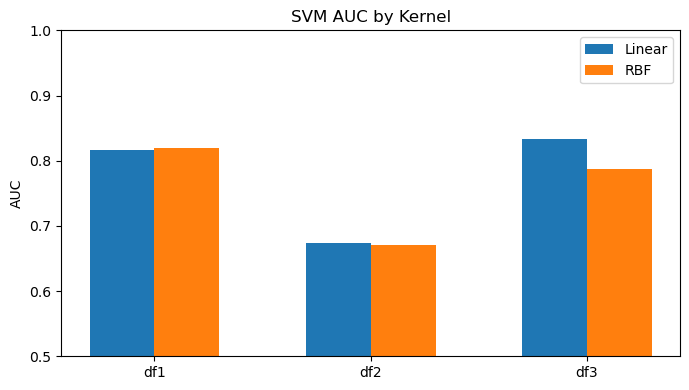

In [14]:
summary = pd.DataFrame({
    'Dataset': ['df1', 'df2', 'df3'],
    'Linear': [auc1_lin, auc2_lin, auc3_lin],
    'RBF':    [auc1_rbf, auc2_rbf, auc3_rbf]
})
print(summary.to_string(index=False))

x = np.arange(3)
w = 0.3
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - w/2, summary['Linear'], w, label='Linear')
ax.bar(x + w/2, summary['RBF'], w, label='RBF')
ax.set_xticks(x)
ax.set_xticklabels(['df1', 'df2', 'df3'])
ax.set_ylabel('AUC')
ax.set_title('SVM AUC by Kernel')
ax.set_ylim(0.5, 1.0)
ax.legend()
plt.tight_layout()
plt.show()